# Plotting and visualization
Here we use [Matplotlib](https://matplotlib.org/) to create different types of visualizations. The structure of a visualization in Matplolib is based on a figure, that represents a canvas, and axes that represent coordinate systems. We can use one or more axes organized in blocks in a grid within a figure. The examples in this notebook follow those from chapter 4 of the book by Johansson [*Numerical Python, 3rd Edition*](https://github.com/jrjohansson/numerical-python-book-code/blob/master/ch04-code-listing.ipynb). 

In [1]:
import numpy as np
import sympy
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('SciPy version: {}'.format(scipy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
SciPy version: 1.17.1
Matplotlib version: 3.8.4


## 2D line plot
We start by plotting a function $y=f(x)$ and its first and second derivatives. We use the NumPy linspace() function to create an array of real values for the x variable, then we define the function $f$ and its derivates.  

In [2]:
x = np.linspace(-5, 2, 100)
y = x**3 + 5*x**2 + 10
y_1 = 3*x**2 + 10*x # 1st derivative
y_2 = 6*x + 10 # 2nd derivative

We create the canvas and we use one axis, that is one coordinate system, since we want a plot with the function $f$ and its derivatives in the same space. We pass the x array and the function definition to the plot() method of the axis

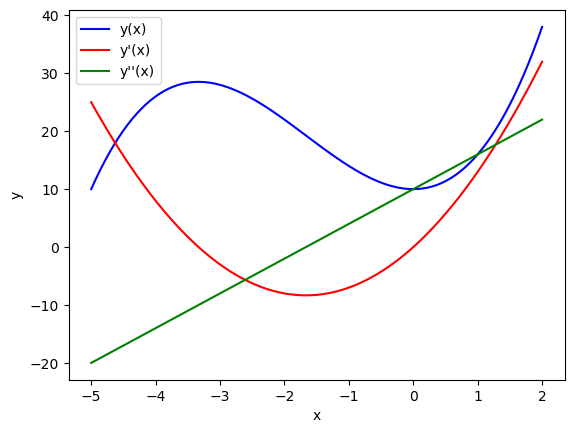

In [3]:
fig, ax = plt.subplots()
ax.plot(x, y, color="blue", label="y(x)")
ax.plot(x, y_1, color="red", label="y'(x)")
ax.plot(x, y_2, color="green", label="y''(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

## The figure element
We can change the width and height of the canvas and set the number of pixels for each of them. We first need to set the figure's size in inches and then we set the resolution in dpi, that is the number of pixel per inch. 

In [4]:
x = np.linspace(-2, 2, 1000)
y1 = np.cos(40 * x)
y2 = np.exp(-x**2)

The axes coordinates are fractions of the canvas width and height

Text(0, 0.5, 'y')

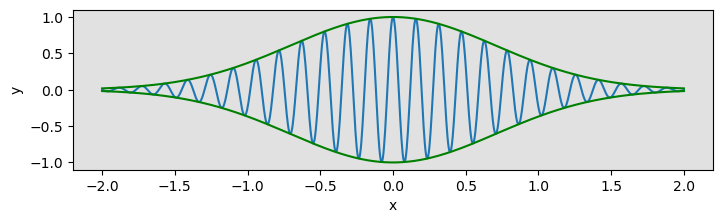

In [5]:
fig_width = 8.0
fig_height = 2.0
fig = plt.figure(figsize=(fig_width, fig_height), dpi=100)
left, bottom, width, height = 0.0, 0.0, 0.8, 0.8
ax = fig.add_axes((left, bottom, width, height), facecolor="#e1e1e1")
ax.plot(x, y1 * y2)
ax.plot(x, y2, 'g')
ax.plot(x, -y2, 'g')
ax.set_xlabel("x")
ax.set_ylabel("y")

## The axis element
The axes can be positioned everywhere in the figure's canvas. They have a cordinates system and are the elements used to create several types of plots. The subplots() function can be used to create a grid of e.g. 3 rows times two columns of axes within a canvas.

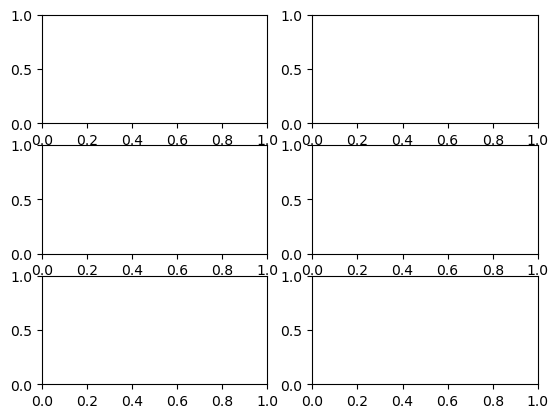

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=2)

### Line plot
The axis object provides methods to create several types of plot: line plot, scatter plot, histograms, bar plot 

In [7]:
x = np.linspace(-3, 3, 25)
y1 = x**3+ 3 * x**2 + 10
y2 = -1.5 * x**3 + 10*x**2 - 15

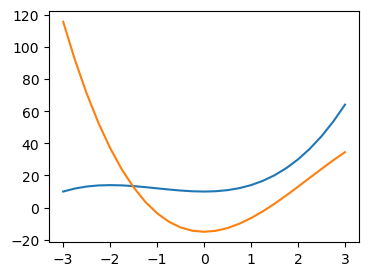

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y1)
ax.plot(x, y2)

We may want to remove the ticks label from a plot

In [9]:
fignum = 0
def hide_labels(fig, ax):
    global fignum
    ax.set_xticks([])
    ax.set_yticks([])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.axis('tight')

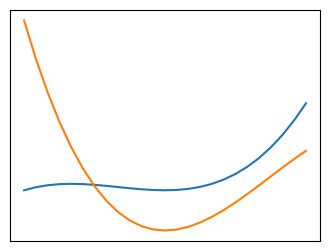

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x, y1)
ax.plot(x, y2)
hide_labels(fig, ax)

### Bar plot

<BarContainer object of 25 artists>

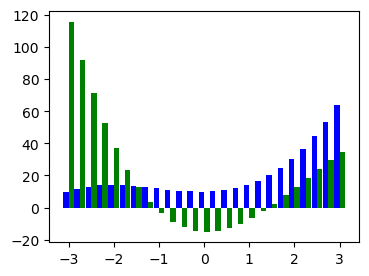

In [11]:
fig, ax = plt.subplots(figsize=(4, 3))
width = 6/50.0
ax.bar(x - width/2, y1, width=width, color="blue")
ax.bar(x + width/2, y2, width=width, color="green")

### Histograms

(array([7., 6., 4., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.]),
 array([10. , 11.8, 13.6, 15.4, 17.2, 19. , 20.8, 22.6, 24.4, 26.2, 28. ,
        29.8, 31.6, 33.4, 35.2, 37. , 38.8, 40.6, 42.4, 44.2, 46. , 47.8,
        49.6, 51.4, 53.2, 55. , 56.8, 58.6, 60.4, 62.2, 64. ]),
 <BarContainer object of 30 artists>)

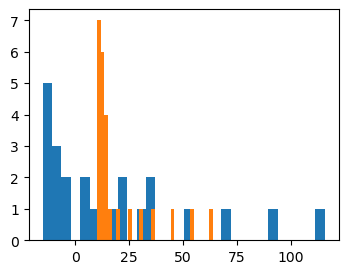

In [12]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(y2, bins=30)
ax.hist(y1, bins=30)

### Error bars

<ErrorbarContainer object of 3 artists>

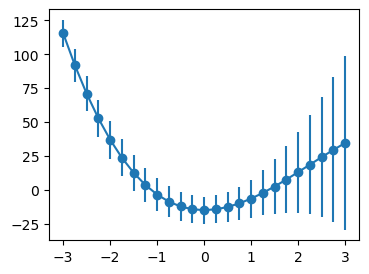

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.errorbar(x, y2, yerr=y1, fmt='o-')

### Scatter plot

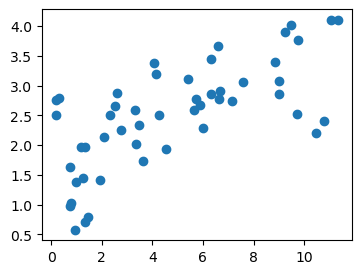

In [14]:
fig, ax = plt.subplots(figsize=(4, 3))
t = np.linspace(0, 5, 50)
x = -1 + t + 0.25 * t**2 + 2 * np.random.rand(len(t))
y = np.sqrt(t) + 2 * np.random.rand(len(t))
ax.scatter(x,y)

## 2D vector field
In order to plot a vector field we need a grid (X,Y) of points that will be used as the origins of vectors and the values (U,V) of the components. X and Y are 2D arrays that contain the x and y coordinate values for each point of the grid.

In [53]:
x = y = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x, y)
U = np.sin(X)
V = np.sin(Y)

Matplotlib provides the [quiver](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) method to plot 2D vectors

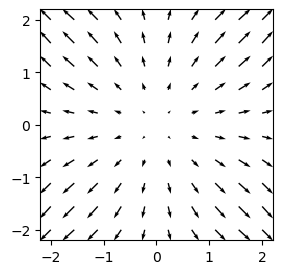

In [52]:
fig, ax = plt.subplots(figsize=(3, 3))
colors = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral']
ax.quiver(X, Y, U, V)

## Line properties
A line is built from points. Both points and lines have properties that change the way they are visualized. A line's properties are width and style. A point's properties are type, size and color. We create four plots to show these properties.

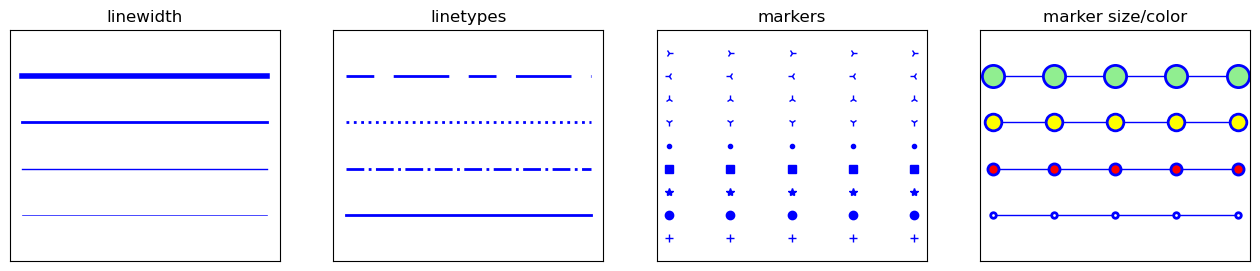

In [16]:
x = np.linspace(-5, 5, 5)
y = np.ones_like(x)

def axes_settings(fig, ax, title, ymax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(0, ymax+1)
    ax.set_title(title)

fig, axes = plt.subplots(1, 4, figsize=(16,3))
# Line width
linewidths = [0.5, 1.0, 2.0, 4.0]
for n, linewidth in enumerate(linewidths):
    axes[0].plot(x, y + n, color="blue", linewidth=linewidth)
axes_settings(fig, axes[0], "linewidth", len(linewidths))

# Line style
linestyles = ['-', '-.', ':']
for n, linestyle in enumerate(linestyles):
    axes[1].plot(x, y + n, color="blue", lw=2, linestyle=linestyle)

# custom dash style
line, = axes[1].plot(x, y + 3, color="blue", lw=2)
length1, gap1, length2, gap2 = 10, 7, 20, 7
line.set_dashes([length1, gap1, length2, gap2])
axes_settings(fig, axes[1], "linetypes", len(linestyles) + 1)

# marker types
markers = ['+', 'o', '*', 's', '.', '1', '2', '3', '4']
for n, marker in enumerate(markers):
    # lw = shorthand for linewidth, ls = shorthand for linestyle
    axes[2].plot(x, y + n, color="blue", lw=2, ls='None', marker=marker)
axes_settings(fig, axes[2], "markers", len(markers))
    
    
# marker size and color
markersizecolors = [(4, "white"), (8, "red"), (12, "yellow"), (16, "lightgreen")]
for n, (markersize, markerfacecolor) in enumerate (markersizecolors):
    axes[3].plot(x, y + n, color="blue", lw=1, ls='-',
                 marker='o', markersize=markersize,
                 markerfacecolor=markerfacecolor, markeredgewidth=2)
    
axes_settings(fig, axes[3], "marker size/color", len (markersizecolors))

One more example to show how to use the line's properties to underline one element of a plot. We build the Taylor expansion of the sin(x) function, form order 2 to order 12 and we plot all of them in the same canvas using different line types and widths. We start by defining a function that creates the Taylor expansions in symbols

In [3]:
sym_x = sympy.Symbol("x")
def sin_symbolic_expansion(sim_x, n):
    '''
    Symbolic Taylor expansion of order n of the sin(x) function
    '''
    return sympy.sin(sym_x).series(sym_x, 0, n = n + 1)

In [4]:
sin_symbolic_expansion(sym_x, 7)

x - x**3/6 + x**5/120 - x**7/5040 + O(x**8)

We define a function that calculates the numerical values of a Taylor series using the [SymPy's lambdify()](https://docs.sympy.org/latest/modules/utilities/lambdify.html) function

In [5]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 100)
def sin_numerical_expansion(sym_x, x, n):
    """
    Evaluate the nth order Talyor series expansion
    of sin(x) for the numerical values in the array x.
    """
    return sympy.lambdify(sym_x, sin_symbolic_expansion(sym_x, n).removeO(), 'numpy')(x)

Finally we plot the sin(x) function and its Taylor expansions from order 2 to order 12

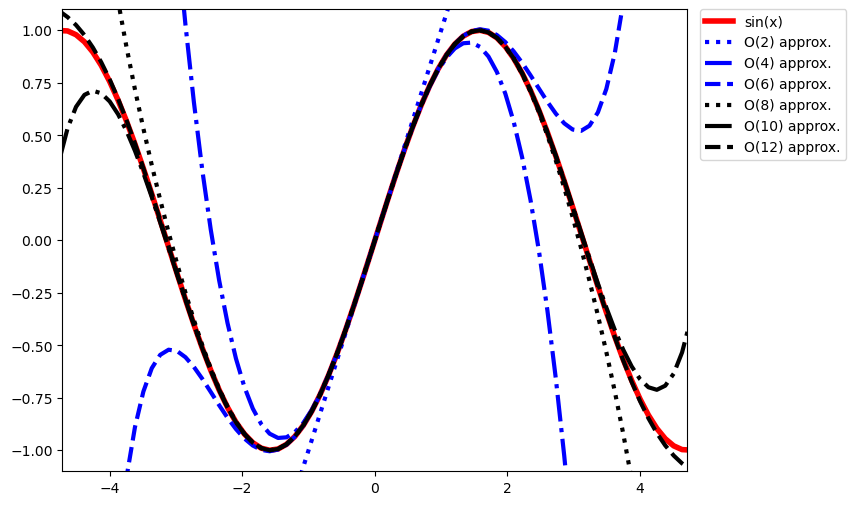

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, np.sin(x), linewidth=4, color="red", label='sin(x)')
colors = ["blue", "black"]
linestyles = [':', '-.', '--']

for idx, n in enumerate(range(1, 12, 2)):
    ax.plot(x, sin_numerical_expansion(sym_x, x, n), color=colors[idx // 3],
            linestyle=linestyles[idx % 3], linewidth=3, # or lw=3
            label="O(%d) approx." % (n+1))
    
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(-1.5*np.pi, 1.5*np.pi)
ax.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0.0)
fig.subplots_adjust(right=.75);

## Ticks, tick labels, and grids

Text(0.5, 1.0, 'major locator')

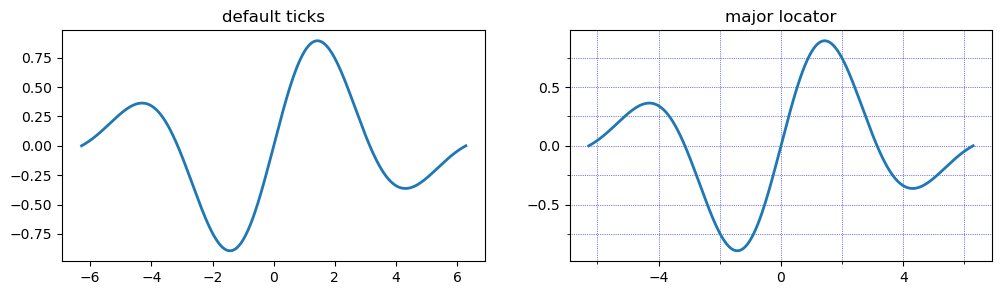

In [14]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 500)
y = np.sin(x) * np.exp(-x**2/20)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(x, y, lw=2) # lw=linewidth
axes[0].set_title("default ticks")

axes[1].plot(x, y, lw=2)
axes[1].xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
axes[1].yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
axes[1].xaxis.set_minor_locator(mpl.ticker.MaxNLocator(8))
axes[1].yaxis.set_minor_locator(mpl.ticker.MaxNLocator(8))
axes[1].grid(color="blue", which="both", linestyle=':', linewidth=0.5)
axes[1].set_title("major locator")

## Log plots
There are two methods to draw log plots. One is to use the loglog() or semilogx() and semilogy() functions to plot both coordinates or only the x or y log values respectively. The second method is to set the axix's x or y scales to 'log'.

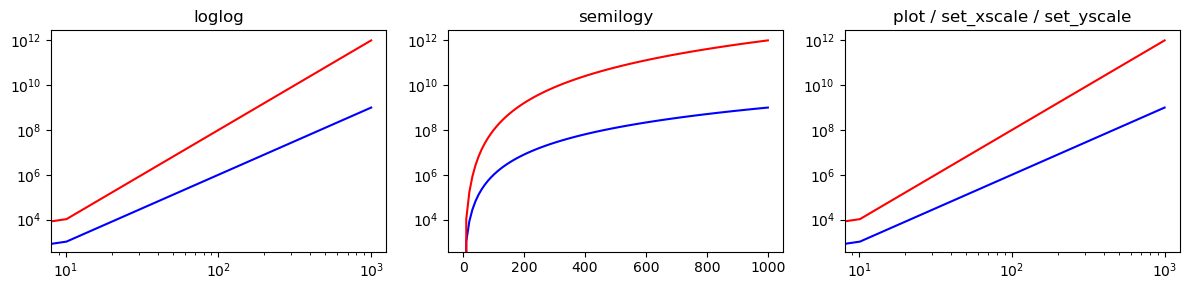

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

x = np.linspace(0, 1e3, 100)
y1, y2 = x**3, x**4

axes[0].set_title('loglog')
axes[0].loglog(x, y1, 'b', x, y2, 'r')

axes[1].set_title('semilogy')
axes[1].semilogy(x, y1, 'b', x, y2, 'r')

axes[2].set_title('plot / set_xscale / set_yscale')
axes[2].plot(x, y1, 'b', x, y2, 'r')
axes[2].set_xscale('log')
axes[2].set_yscale('log')

fig.tight_layout()

## Twin axes
We may want to plot two functions in the same canvas that share the same x interval but with different values and meaning for the dependent variables

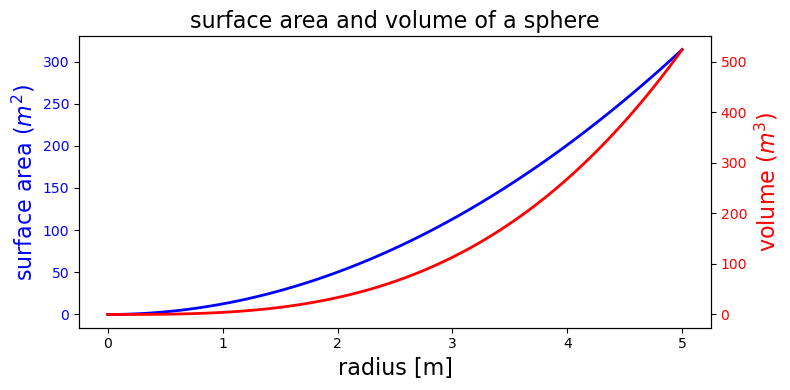

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 4))

r = np.linspace(0, 5, 100)
a = 4 * np.pi * r ** 2  # area
v = (4 * np.pi / 3) * r ** 3  # volume


ax1.set_title("surface area and volume of a sphere", fontsize=16)
ax1.set_xlabel("radius [m]", fontsize=16)

ax1.plot(r, a, lw=2, color="blue")
ax1.set_ylabel(r"surface area ($m^2$)", fontsize=16, color="blue")
for label in ax1.get_yticklabels():
    label.set_color("blue")
    
ax2 = ax1.twinx()
ax2.plot(r, v, lw=2, color="red")
ax2.set_ylabel(r"volume ($m^3$)", fontsize=16, color="red")
for label in ax2.get_yticklabels():
    label.set_color("red")
    
fig.tight_layout()

## Spines
We may want to change or remove all or parts of the box around a plot

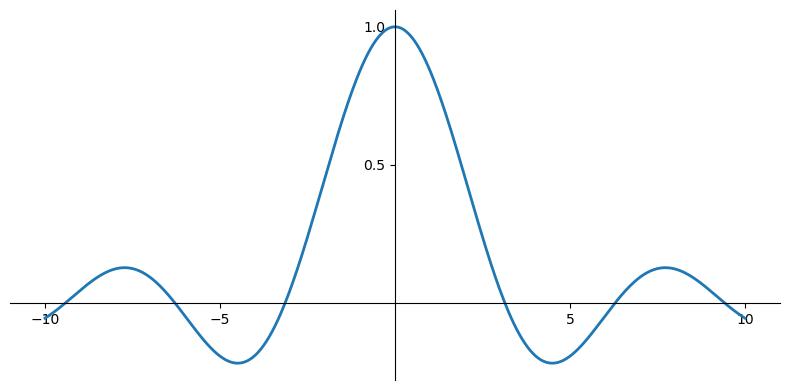

In [22]:
x = np.linspace(-10, 10, 500)
y = np.sin(x) / x

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, linewidth=2)

# remove top and right spines
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# remove top and right spine ticks
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# move bottom and left spine to x = 0 and y = 0
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
    
ax.set_xticks([-10, -5, 5, 10])
ax.set_yticks([0.5, 1])

# give each label a solid background of white, to not overlap with the plot line
#for label in ax.get_xticklabels() + ax.get_yticklabels():
#    label.set_bbox({'facecolor': 'white',
#                    'edgecolor': 'white'})
    
fig.tight_layout()

## Insets
We might want to add a subplot somewhere inside another plot, for example to expand a section of the main plot.

In [4]:
def f(x):
    return 1/(1 + x**2) + 0.1/(1 + ((3 - x)/0.1)**2)

def plot_and_format_axes(ax, x, f, fontsize):
    ax.plot(x, f(x), linewidth=2)
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.set_xlabel(r"$x$", fontsize=fontsize)
    ax.set_ylabel(r"$f(x)$", fontsize=fontsize)

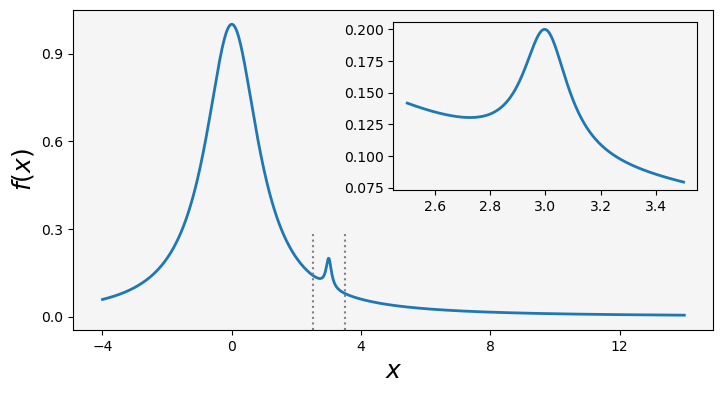

In [7]:
fig = plt.figure(figsize=(8, 4))    
# main graph
ax = fig.add_axes([0.1, 0.15, 0.8, 0.8], facecolor="#f5f5f5")
x = np.linspace(-4, 14, 1000)
plot_and_format_axes(ax, x, f, 18)

# inset
x0, x1 = 2.5, 3.5
ax.axvline(x0, ymax=0.3, color="grey", linestyle=":")
ax.axvline(x1, ymax=0.3, color="grey", linestyle=":")

ax = fig.add_axes([0.5, 0.5, 0.38, 0.42], facecolor='none')
x = np.linspace(x0, x1, 1000)
#plot_and_format_axes(ax, x, f, 14)
ax.plot(x, f(x), linewidth=2)

## Subplots
We have seen before how to create a grid of subplots (axes) withis a canvas (figure). Here we use other features of subplots. We will see also other layout managers other than subplot()

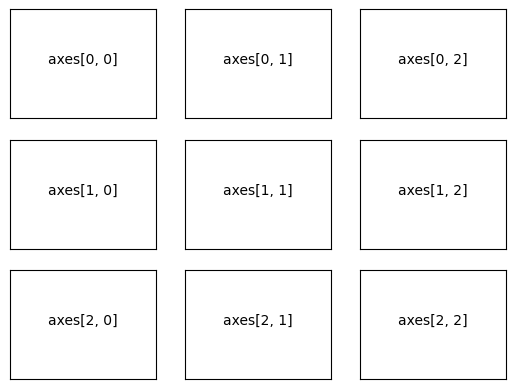

In [11]:
ncols, nrows = 3, 3

fig, axes = plt.subplots(nrows, ncols)

for m in range(nrows):
    for n in range(ncols):
        axes[m, n].set_xticks([])
        axes[m, n].set_yticks([])
        axes[m, n].text(0.5, 0.5, "axes[%d, %d]" % (m, n), horizontalalignment='center')

One feature of subplots is that they can share the x or the y axis so when we draw plots in a grid that share the x and y intervals the ticks and the labels will appear only once on the left or at the bottom and not for every axis. For this example we use a scatter plots of two random functions.

In [13]:
x1 = np.random.randn(100)
x2 = np.random.randn(100)

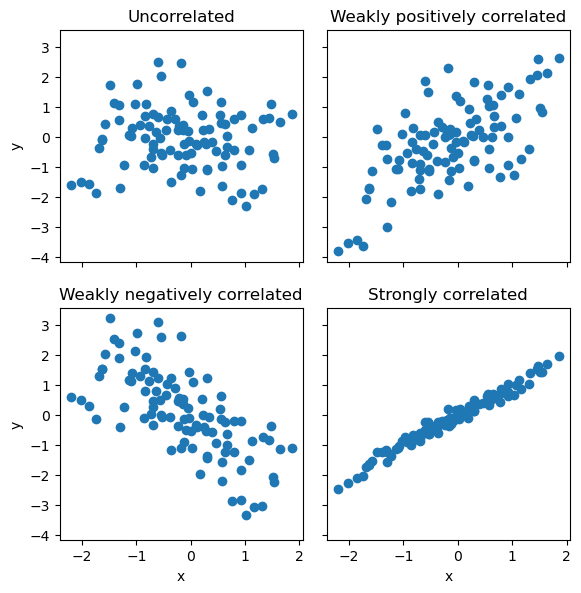

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True, squeeze=False)

axes[0, 0].set_title("Uncorrelated")
axes[0, 0].scatter(x1, x2)

axes[0, 1].set_title("Weakly positively correlated")
axes[0, 1].scatter(x1, x1 + x2)

axes[1, 0].set_title("Weakly negatively correlated")
axes[1, 0].scatter(x1, -x1 + x2)

axes[1, 1].set_title("Strongly correlated")
axes[1, 1].scatter(x1, x1 + 0.15 * x2)

axes[1, 1].set_xlabel("x")
axes[1, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[1, 0].set_ylabel("y")

plt.subplots_adjust(left=0.1, right=0.95, bottom=0.1, top=0.95, wspace=0.1, hspace=0.2)

We can change the size and position of the axes in a grid using the subplot2grid() layout manager

In [4]:
def clear_ticklabels(ax):
    ax.set_yticklabels([])
    ax.set_xticklabels([])

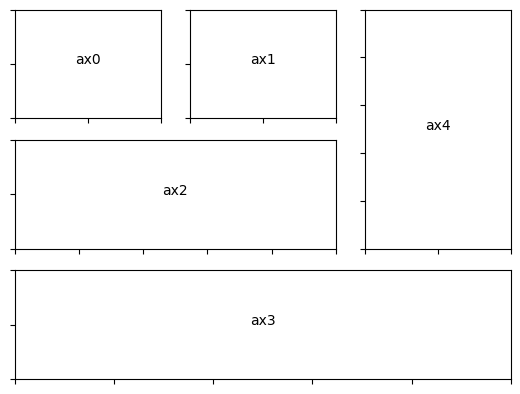

In [5]:
fig = plt.figure()
    
ax0 = plt.subplot2grid((3, 3), (0, 0))
ax1 = plt.subplot2grid((3, 3), (0, 1))
ax2 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
ax3 = plt.subplot2grid((3, 3), (2, 0), colspan=3)
ax4 = plt.subplot2grid((3, 3), (0, 2), rowspan=2)

axes = [ax0, ax1, ax2, ax3, ax4]

[ax.text(0.5, 0.5, "ax%d" % n, horizontalalignment='center') for n, ax in enumerate(axes)];
[clear_ticklabels(ax) for ax in axes];

In [6]:
from matplotlib.gridspec import GridSpec

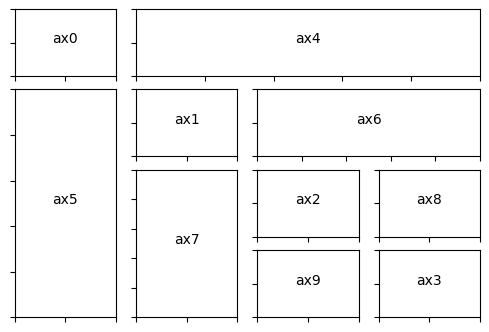

In [7]:
fig = plt.figure(figsize=(6, 4))

gs = mpl.gridspec.GridSpec(4, 4)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 1])
ax2 = fig.add_subplot(gs[2, 2])
ax3 = fig.add_subplot(gs[3, 3])
ax4 = fig.add_subplot(gs[0, 1:])
ax5 = fig.add_subplot(gs[1:, 0])
ax6 = fig.add_subplot(gs[1, 2:])
ax7 = fig.add_subplot(gs[2:, 1])
ax8 = fig.add_subplot(gs[2, 3])
ax9 = fig.add_subplot(gs[3, 2])

axes = [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
[ax.text(0.5, 0.5, "ax%d" % n, horizontalalignment='center') for n, ax in enumerate(axes)];
[clear_ticklabels(ax) for ax in axes];

## Colormap plot
We can represent 3D functions in 2D plots using color shades (heatmaps) as the 3rd dimension. Matplotlib provides 4 methods to display a function of the type $z=f(x,y)$: pcolor(), imshow(), contour(), and contourf(). 

### pcolormesh
The [pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html#) method is used to plot a function of the type $Z=f(X,Y)$. X and Y are 2D arrays of the x and y values of a grid. The two arrays are used to calculate the corresponding z values and assign them to a 2D Z array. The three 2D arrays X, Y, and Z are finally passed to pcolor that uses them to plot Z over the (X,Y) grid. 

In [11]:
x = y = np.linspace(-2, 2, 150)
X, Y = np.meshgrid(x, y)
print('X array: {}\nY array: {}'.format(X.shape, Y.shape))

X array: (150, 150)
Y array: (150, 150)


we define a function and calculate its values over the (X,Y) points of the grid

In [12]:
R1 = np.sqrt((X + 0.5)**2 + (Y + 0.5)**2)
R2 = np.sqrt((X + 0.5)**2 + (Y - 0.5)**2)
R3 = np.sqrt((X - 0.5)**2 + (Y + 0.5)**2)
R4 = np.sqrt((X - 0.5)**2 + (Y - 0.5)**2)
Z = np.sin(10 * R1) / (10 * R1) + np.sin(20 * R4) / (20 * R4)

Since the z values are shown as color shades we need a [color map](https://matplotlib.org/stable/api/cm_api.html) to map each z value to a color and a [color bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.colorbar.html#matplotlib.figure.Figure.colorbar) next to the plot to visualize the meaning of the color at each grid point. Many color maps are available from Matplotlib and it is also possible to create new ones.

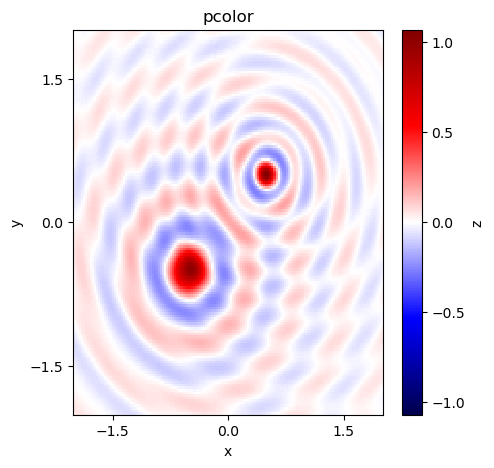

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
p = ax.pcolormesh(X, Y, Z, cmap='seismic', vmin=-abs(Z).max(), vmax=abs(Z).max())
ax.axis('tight')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title("pcolor")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
cb = fig.colorbar(p, ax=ax)
cb.set_label("z")
cb.set_ticks([-1, -.5, 0, .5, 1])

### imshow
The imshow() method can be used to plot an image or any 2D array of values so it doesn't need the X and Y 2D arrays, it only uses one 2D array. The number of pixels depends on the size of the canvas, that is figure height and width in inch and the number of pixels (dots) per inch or dpi. If the number of pixels in the canvas is different from the size of the 2D array the imshow() method performs a [resampling](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_antialiasing.html) using an interpolation algorithm. The resampling translates in a downsampling if the size of the input array is higher than that of the canvas or an upsampling otherwise.  

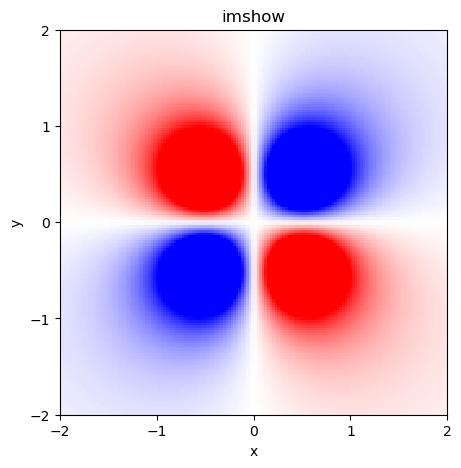

In [40]:
Z = 1/R1 - 1/R2 - 1/R3 + 1/R4
fig_width = 5.0
fig_height = 5.0
fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=100)
im = ax.imshow(Z, vmin=-1, vmax=1, cmap=mpl.cm.bwr, extent=[x.min(), x.max(), y.min(), y.max()])
im.set_interpolation('nearest')
ax.axis('tight')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title("imshow")
cb = fig.colorbar(im, ax=axes[1])
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
#cb.ax.set_axes_locator(mpl.ticker.MaxNLocator(4))
cb.set_label("z")
cb.set_ticks([-1, -.5, 0, .5, 1])

### Contour
The contour() method works like pcolor() in that it needs three 2D arrays for X, Y and Z values but draws only lines at certain Z values for a number of levels. We define a new (X,Y) grid and a function with its Z values.

In [44]:
x = y = np.linspace(0, 1, 75)
X, Y = np.meshgrid(x, y)
Z = - 2 * np.cos(2 * np.pi * X) * np.cos(2 * np.pi * Y) - 0.7 * np.cos(np.pi - 4*np.pi*X)

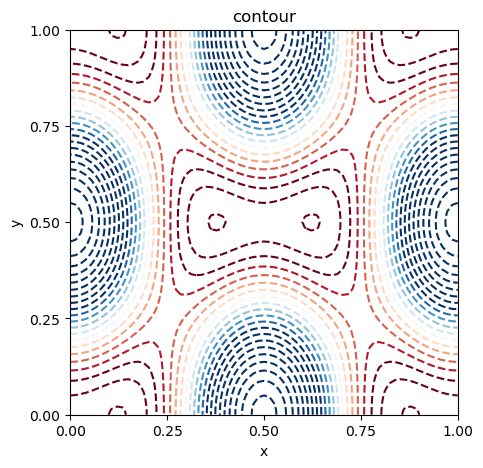

In [46]:
fig, ax = plt.subplots(figsize=(5, 5))
c = ax.contour(X, Y, Z, 
               levels=25,
               linestyles='dashed',
               cmap=mpl.cm.RdBu, 
               vmin=-1, vmax=1)
ax.axis('tight')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title("contour")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))

### Contourf
The [contourf()](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contourf.html#matplotlib.axes.Axes.contourf) method works like contour() but filling the space between contour lines

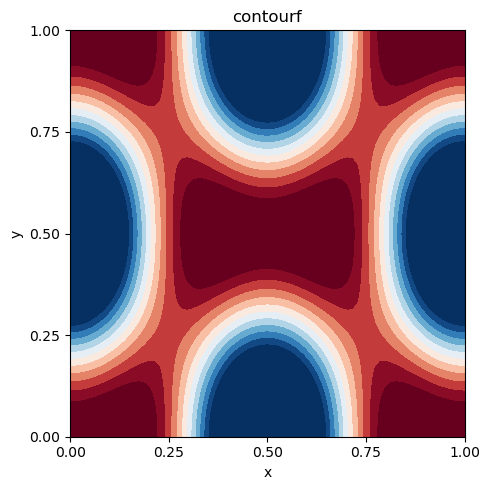

In [48]:
fig, ax = plt.subplots(figsize=(5, 5))
c = ax.contourf(X, Y, Z, levels=25, cmap=mpl.cm.RdBu, vmin=-1, vmax=1)
ax.axis('tight')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title("contourf")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))

fig.tight_layout()

We plot the same data using pcolor() to show the difference with contourf().

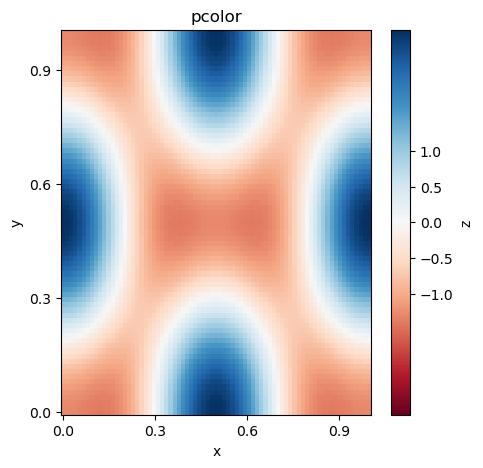

In [50]:
fig, ax = plt.subplots(figsize=(5, 5))
p = ax.pcolor(X, Y, Z, cmap=mpl.cm.RdBu, vmin=-abs(Z).max(), vmax=abs(Z).max())
ax.axis('tight')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title("pcolor")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
cb = fig.colorbar(p, ax=ax)
cb.set_label("z")
cb.set_ticks([-1, -.5, 0, .5, 1])

## 3D plots
Another way to visualize functions of the type $z=f(x,y)$ is to use a 3D reference frame. We need three 2D arrays for X,Y and Z with Z calculated from the function definition and the (X,Y) values in the grid. We need to import the [Axes3D module](https://matplotlib.org/stable/api/toolkits/mplot3d/axes3d.html#) to use the plotting functions in 3 dimensions.

In [3]:
from mpl_toolkits.mplot3d.axes3d import Axes3D

In [2]:
x = y = np.linspace(-3, 3, 74)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X ** 2 + Y ** 2)
Z = np.sin(4 * R) / R

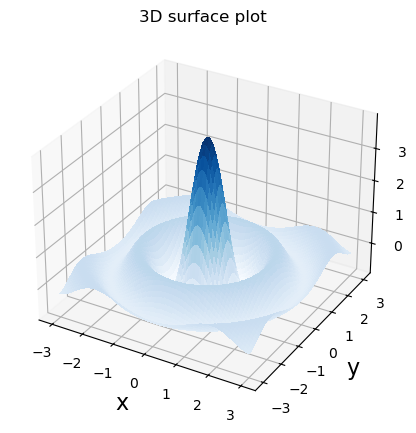

In [3]:
fig, ax = plt.subplots(figsize=(5.0, 5.0), subplot_kw={'projection': '3d'})
p = ax.plot_surface(X, Y, Z, 
                    rstride=1, 
                    cstride=1, 
                    linewidth=0, 
                    antialiased=False,
                   cmap=mpl.cm.Blues)
#cb = fig.colorbar(p, ax=ax, shrink=0.6, pad=0.2)
ax.set_xlabel('x', fontsize=16)
ax.set_ylabel('y', fontsize=16)
ax.set_zlabel('z', fontsize=16)
ax.set_title('3D surface plot');

We can plot a unit sphere by calculating the cartesian coordinates X,Y,Z from the spherical coordinates $\theta$ and $\phi$, with $r=1$

In [4]:
start_theta = 0.0
stop_theta = 2 * np.pi
steps_theta = 40j
start_phi = 0.0
stop_phi = np.pi
steps_phi = 20j 
theta, phi = np.mgrid[start_theta : stop_theta : steps_theta, start_phi : stop_phi : steps_phi]
X = np.cos(theta)*np.sin(phi)
Y = np.sin(theta)*np.sin(phi)
Z = np.cos(phi)

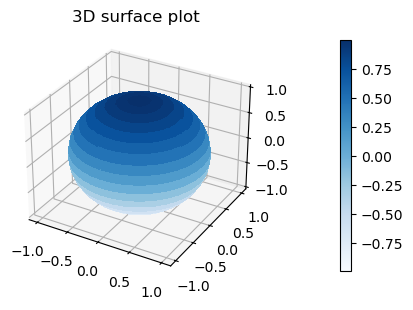

In [5]:
fig, ax = plt.subplots(figsize=(5.0, 5.0), subplot_kw={'projection': '3d'})
p = ax.plot_surface(X, Y, Z, 
                    rstride=1, 
                    cstride=1, 
                    linewidth=0, 
                    antialiased=False,
                    cmap=mpl.cm.Blues)
cb = fig.colorbar(p, ax=ax, shrink=0.6, pad=0.2)
ax.set_title('3D surface plot');

### Plotting scalar functions on a sphere
Like for the 2D colormaps we can use color shades to represent the value of a function on a 3D surface, or example a sphere. In this example the color value of each point represents the value of a spherical harmonic on the sphere. This is different from representing the spherical harmonic that has a different nonspherical 3D shape. This representation can be used to plot the temperature field, the pressure field on the Earth surface.  

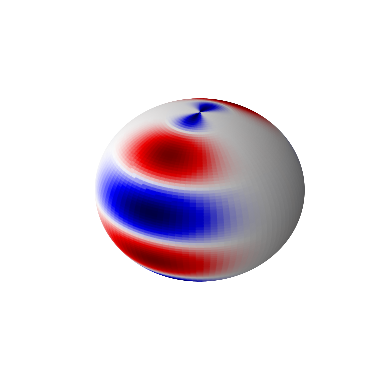

In [11]:
from scipy.special import sph_harm_y
from matplotlib import cm, colors

phi = np.linspace(0, np.pi, 100)
theta = np.linspace(0, 2 * np.pi, 100)
phi, theta = np.meshgrid(phi, theta)

# The Cartesian coordinates of the unit sphere
x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)

m, l = 5, 5

# Calculate the spherical harmonic Y(l,m) and normalize to [0,1]
fcolors = sph_harm_y(l, m, theta, phi).real
fmax, fmin = fcolors.max(), fcolors.min()
fcolors = (fcolors - fmin) / (fmax - fmin)

# Set the aspect ratio to 1 so our sphere looks spherical
fig = plt.figure(figsize=plt.figaspect(1.0))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=cm.seismic(fcolors))
# Turn off the axis planes
ax.set_axis_off()

We can easily draw a trajectory in a 3D reference system

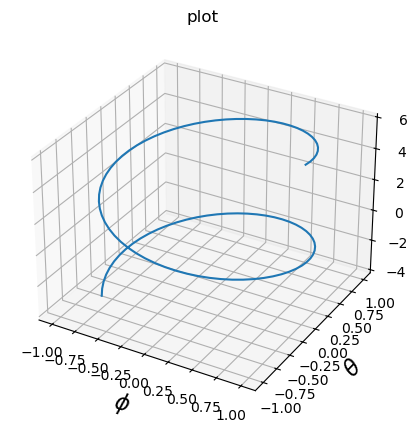

In [4]:
fig, ax = plt.subplots(figsize=(5.0, 5.0), subplot_kw={'projection': '3d'})
ax.set_title('plot')
ax.set_xlabel("$\\phi$", fontsize=16)
ax.set_ylabel("$\\theta$", fontsize=16)
ax.set_zlabel("$z$", fontsize=16)
r = np.linspace(0, 10, 100)
p = ax.plot(np.cos(r), np.sin(r), 6 - r)
#cb = fig.colorbar(p, ax=axes[0], shrink=0.6)